# 01 — Comparación Nacional vs Regional

Compara el escenario **SAND Nacional** contra el **Regional** (7 regiones con prefijo
en `TECHNOLOGY`/`FUEL`), conducido por los índices de cada parámetro según
`config_depurado.yaml`:

- **Aditivos**: nacional == suma de las regiones (excluyendo centinelas 99999/solo-9s).
- **Intensivos** (`parametros_intensivos` en `config/params_config.yaml`): cada región
  debe conservar el valor nacional.
- Parámetros sin `YEAR` se comparan por `Time indipendent variables`.

Genera un Excel con hojas **Comparacion** (resaltado rojo sobre el umbral),
**Anomalias** y **Resumen**, y una gráfica Top-N exportada a PNG.

> Ejecutable de principio a fin con *Run All*.

In [1]:
# --- Setup: raíz del proyecto, módulos src/ y configuración ---
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

RAIZ = Path.cwd().resolve()
if not (RAIZ / "config").exists():   # ejecutado desde notebooks/
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

import comparador
import regionalizador
import reporte
import sand_io
import utils
import yaml_parser

utils.configurar_logging()

params_cfg = yaml_parser.cargar_params_config(RAIZ / "config" / "params_config.yaml")
paths = yaml_parser.cargar_paths_config(RAIZ / "config" / "paths_config.yaml", raiz=RAIZ)
otoole = yaml_parser.cargar_config_otoole(paths["escenario_nacional"]["config_yaml"])

print(f"Nacional : {paths['escenario_nacional']['sand'].name}")
print(f"Regional : {paths['escenario_regional']['sand'].name}")
print(f"Config otoole: {len(otoole['param'])} parámetros, {len(otoole['set'])} sets")
print(f"Intensivos: {len(params_cfg['parametros_intensivos'])} | Centinela: {params_cfg['valor_centinela']}")

Nacional : 01-04-2026 SAND BASE v10.xlsx
Regional : SAND_Regional_17_07.xlsx
Config otoole: 40 parámetros, 8 sets
Intensivos: 16 | Centinela: 99999.0


## 1. Carga de los archivos SAND

In [2]:
df_nacional = sand_io.cargar_sand(paths["escenario_nacional"]["sand"])
df_regional = sand_io.cargar_sand(paths["escenario_regional"]["sand"])

anios = sand_io.columnas_anio(df_nacional)
display(pd.DataFrame([
    {"Archivo": "Nacional", "Filas": len(df_nacional),
     "Parametros": df_nacional["Parameter"].nunique(),
     "TECHNOLOGY": df_nacional["TECHNOLOGY"].nunique(), "FUEL": df_nacional["FUEL"].nunique()},
    {"Archivo": "Regional", "Filas": len(df_regional),
     "Parametros": df_regional["Parameter"].nunique(),
     "TECHNOLOGY": df_regional["TECHNOLOGY"].nunique(), "FUEL": df_regional["FUEL"].nunique()},
]))
print(f"Años: {anios[0]}–{anios[-1]} ({len(anios)})")

,Archivo,Filas,Parametros,TECHNOLOGY,FUEL
0,Nacional,69644,38,394,113
1,Regional,30471,31,2596,580


Años: 2022–2055 (34)


## 2. Filtros de la comparación

- `MODO_COMPARACION`: `'general'` (todos los parámetros), `'parametro'` o `'lista_parametros'`.
- `TECNOLOGIAS_A_FILTRAR` / `FUELS_A_FILTRAR` solo actúan sobre parámetros indexados
  por esa dimensión; `MODO_FILTRO` = `'exacto'` o `'contiene'`.

In [3]:
MODO_COMPARACION = "lista_parametros"   # 'general' | 'parametro' | 'lista_parametros'
PARAMETROS_FILTRO = ["AccumulatedAnnualDemand", "TotalTechnologyAnnualActivityLowerLimit"]
TECNOLOGIAS_A_FILTRAR = []              # solo activo si el parámetro se indexa por TECHNOLOGY
FUELS_A_FILTRAR = []                    # solo activo si el parámetro se indexa por FUEL
MODO_FILTRO = "exacto"                  # 'exacto' | 'contiene'

TOP_N = params_cfg["top_n_grafica"]     # Top-N de la gráfica/tabla de diferencias
UMBRAL_ALERTA = params_cfg["umbral_alerta_pct"]

## 2b. Inventario de parámetros, tecnologías y fuels

Análisis estructural (solo con `MODO_COMPARACION == 'general'`): distribución de
parámetros entre archivos, inventario `TECHNOLOGY`/`FUEL` por código base (prefijos
separados con `split_regional_name`) y renombramientos conocidos vía los diccionarios
de `Insumos/Mapeo/` — sin diccionario de FUEL cae a detección fuzzy (`difflib`, umbral 0.8).

In [4]:
# --- 2b. Inventario estructural (comparador.inventario_tech_fuel) ---
MAPEOS = comparador.cargar_mapeos(RAIZ / "Insumos" / "Mapeo")
inventario = None

if MODO_COMPARACION != "general":
    display(Markdown("_Sección 2b omitida: hay filtros activos "
                     f"(`MODO_COMPARACION = '{MODO_COMPARACION}'`). "
                     "Usar `'general'` para el inventario completo._"))
else:
    inventario = comparador.inventario_tech_fuel(
        df_nacional, df_regional, list(params_cfg["prefijo_region"].values()),
        diccionario_tech=MAPEOS["diccionario_tech"],
        diccionario_fuel=MAPEOS["diccionario_fuel"],
    )

    # 2b.1 Distribución de parámetros
    par = inventario["parametros"]
    display(Markdown("### 2b.1 Distribución de parámetros"))
    display(par.groupby("Categoria", as_index=False).size())
    display(par[["Parameter", "Descripcion", "En_Nacional", "En_Regional",
                 "Filas_Nacional", "Filas_Regional", "Categoria"]])
    solo_nac_par = par[par["Categoria"] == "Solo Nacional"]
    if not solo_nac_par.empty:
        display(Markdown(
            f"**Parámetros solo en Nacional ({len(solo_nac_par)})** — suelen ser "
            "restricciones agregadas que no aplican al modelo desagregado:"))
        display(solo_nac_par[["Parameter", "Descripcion", "Filas_Nacional"]]
                .style.hide(axis="index")
                .set_properties(**{"background-color": "#FFC7CE", "color": "#9C0006"}))

    # 2b.2 / 2b.3 Inventario TECHNOLOGY y FUEL
    for titulo, clave in [("2b.2 Inventario TECHNOLOGY", "tech"),
                          ("2b.3 Inventario FUEL", "fuel")]:
        det = inventario[clave]
        display(Markdown(f"### {titulo}"))
        display(det.groupby("Categoria", as_index=False).size())

        solo_nac = det[det["Categoria"] == "Solo Nacional"]
        renombrados = solo_nac[solo_nac["Estado_Mapeo"] == "RENOMBRADO"]
        display(Markdown(
            f"**Solo en Nacional ({len(solo_nac)})** — de ellos, {len(renombrados)} son "
            "renombramientos conocidos (existen en el regional con otro nombre) y "
            f"{len(solo_nac) - len(renombrados)} ausencias reales o sin información:"))
        display(solo_nac[["Variable", "Estado_Mapeo", "Nombre_Equivalente"]])

        solo_reg = det[det["Categoria"].str.startswith("Solo Regional")]
        display(Markdown(f"**Solo en Regional — nuevas o renombradas ({len(solo_reg)})**, "
                         "agrupadas por prefijo temático:"))
        display(solo_reg.groupby(["Grupo", "Categoria"], as_index=False).size()
                .sort_values("size", ascending=False))
        display(solo_reg[["Variable", "Categoria", "Regiones",
                          "Estado_Mapeo", "Nombre_Equivalente"]].head(40))
        display(Markdown(f"**En ambos: {(det['Categoria'] == 'En ambos').sum()} códigos base.**"))

    if not inventario["renombramientos_fuel"].empty:
        display(Markdown("**Renombramientos de FUEL conocidos (Nacional → Regional):**"))
        display(inventario["renombramientos_fuel"])

    display(Markdown(
        "> Nota: las variables renombradas no cuentan como ausencias reales si el mapeo "
        "las identifica (`Estado_Mapeo = RENOMBRADO`); sin diccionario, la detección "
        "fuzzy es solo orientativa."))

12:19:03 INFO    comparador: Mapeo cargado: mapeo_tech_fuel.xlsx (507 filas)


12:19:03 INFO    comparador: Mapeo cargado: diccionario_tech.xlsx (509 filas)


12:19:03 INFO    comparador: Mapeo cargado: diccionario_fuel.xlsx (547 filas)


_Sección 2b omitida: hay filtros activos (`MODO_COMPARACION = 'lista_parametros'`). Usar `'general'` para el inventario completo._

## 3. Comparación

`Región = SUMA_REGIONES` en aditivos; nombre del prefijo regional en intensivos.
El resultado viene ordenado por `|Diferencia|` descendente.

In [5]:
resultado = comparador.comparar_escenarios(
    df_nacional, df_regional, otoole["param"], params_cfg,
    modo=MODO_COMPARACION,
    parametros_filtro=PARAMETROS_FILTRO,
    tecnologias=TECNOLOGIAS_A_FILTRAR,
    fuels=FUELS_A_FILTRAR,
    modo_filtro=MODO_FILTRO,
)
comparacion = resultado["comparacion"]
discrepancias = resultado["discrepancias"]
anomalias = resultado["anomalias"]

print(reporte.resumen_discrepancias(discrepancias, len(comparacion),
                                    params_cfg["tolerancia_comparacion"]))
display(Markdown("**Resumen por parámetro**"))
display(resultado["resumen"])

12:19:03 INFO    comparador: Comparando AccumulatedAnnualDemand ...


12:19:03 INFO    comparador: Comparando TotalTechnologyAnnualActivityLowerLimit ...


12:19:03 INFO    comparador: Comparación terminada: 16434 filas, 2612 discrepancias, 666 anomalías


ALERTA: 2,612 de 16,434 combinaciones superan la tolerancia (0.0001). Diferencia máxima: 372.576583


**Resumen por parámetro**

,Parametro,Tipo,Filas_Comparadas,Filas_Con_Diferencia,Max_Diferencia_Abs,Anomalias,Pct_Parametros_Sin_Diferencia
0,== TOTAL ==,-,16434,2612,372.576583,666,0.000000
1,AccumulatedAnnualDemand,aditivo,3465,961,39.052000,87,NaN
2,TotalTechnologyAnnualActivityLowerLimit,aditivo,12969,1651,372.576583,286,NaN


In [6]:
display(Markdown(f"**Anomalías detectadas: {len(anomalias)}**"))
if not anomalias.empty:
    display(anomalias.groupby("Tipo_Anomalia", as_index=False).size())
    display(anomalias.head(30))

**Anomalías detectadas: 666**

,Tipo_Anomalia,size
0,FUEL_NO_EN_REGIONAL,61
1,REGIONES_INCOMPLETAS,80
2,SIN_CORRESPONDENCIA,293
3,TECHNOLOGY_NO_EN_REGIONAL,232


,Parametro,Tecnologia_Fuel,Tipo_Anomalia,Detalle
0,AccumulatedAnnualDemand,INDCLIM,REGIONES_INCOMPLETAS,Presente en 6 de 7 regiones
1,AccumulatedAnnualDemand,INDDHT,REGIONES_INCOMPLETAS,Presente en 6 de 7 regiones
2,AccumulatedAnnualDemand,INDIHT,REGIONES_INCOMPLETAS,Presente en 6 de 7 regiones
3,AccumulatedAnnualDemand,INDILU,REGIONES_INCOMPLETAS,Presente en 6 de 7 regiones
4,AccumulatedAnnualDemand,INDMPW,REGIONES_INCOMPLETAS,Presente en 6 de 7 regiones
5,AccumulatedAnnualDemand,INDREF,REGIONES_INCOMPLETAS,Presente en 6 de 7 regiones
6,AccumulatedAnnualDemand,OTHDSL,REGIONES_INCOMPLETAS,Presente en 1 de 7 regiones
7,AccumulatedAnnualDemand,OTHELC,REGIONES_INCOMPLETAS,Presente en 1 de 7 regiones
8,AccumulatedAnnualDemand,OTHGSL,REGIONES_INCOMPLETAS,Presente en 1 de 7 regiones
9,AccumulatedAnnualDemand,RESCLIM,REGIONES_INCOMPLETAS,Presente en 2 de 7 regiones


In [7]:
display(Markdown("**Mayores discrepancias**"))
display(discrepancias.head(30))

**Mayores discrepancias**

,Parametro,TECHNOLOGY,FUEL,Año,Region,Valor_Nacional,Valor_Regional,Diferencia,Diferencia_Pct
0,TotalTechnologyAnnualActivityLowerLimit,UPSREF_CAR,NaN,2039,SUMA_REGIONES,372.576583,0.000000,372.576583,1.000000
1,TotalTechnologyAnnualActivityLowerLimit,UPSREF_CAR,NaN,2040,SUMA_REGIONES,372.576583,0.000000,372.576583,1.000000
2,TotalTechnologyAnnualActivityLowerLimit,UPSREF_CAR,NaN,2035,SUMA_REGIONES,372.576583,0.000000,372.576583,1.000000
3,TotalTechnologyAnnualActivityLowerLimit,UPSREF_CAR,NaN,2036,SUMA_REGIONES,372.576583,0.000000,372.576583,1.000000
4,TotalTechnologyAnnualActivityLowerLimit,UPSREF_CAR,NaN,2037,SUMA_REGIONES,372.576583,0.000000,372.576583,1.000000
5,TotalTechnologyAnnualActivityLowerLimit,UPSREF_CAR,NaN,2038,SUMA_REGIONES,372.576583,0.000000,372.576583,1.000000
6,TotalTechnologyAnnualActivityLowerLimit,UPSREF_CAR,NaN,2032,SUMA_REGIONES,372.576583,0.000000,372.576583,1.000000
7,TotalTechnologyAnnualActivityLowerLimit,UPSREF_CAR,NaN,2031,SUMA_REGIONES,372.576583,0.000000,372.576583,1.000000
8,TotalTechnologyAnnualActivityLowerLimit,UPSREF_CAR,NaN,2033,SUMA_REGIONES,372.576583,0.000000,372.576583,1.000000
9,TotalTechnologyAnnualActivityLowerLimit,UPSREF_CAR,NaN,2034,SUMA_REGIONES,372.576583,0.000000,372.576583,1.000000


## 4. Gráfica y tabla Top-N (solo en modo `parametro` / `lista_parametros`)

**Top-20 diferencias absolutas por tecnología/fuel**

,Parametro,Variable,Diferencia_Abs_Total,Max_Diferencia_Abs,Filas
0,TotalTechnologyAnnualActivityLowerLimit,UPSREF_CAR,"6,311.452700",372.576583,33
1,TotalTechnologyAnnualActivityLowerLimit,UPSREF_BAR,"5,710.465614",308.771662,33
2,TotalTechnologyAnnualActivityLowerLimit,DEMAGFDSL,"1,246.927039",61.877979,33
3,AccumulatedAnnualDemand,NGSAUT,"1,176.076000",39.052000,33
4,TotalTechnologyAnnualActivityLowerLimit,DEMAGFWOO,774.472612,38.430154,33
5,AccumulatedAnnualDemand,TRALDV,568.562771,18.672545,33
6,AccumulatedAnnualDemand,NSEELC,551.612783,16.828684,33
7,AccumulatedAnnualDemand,CONSGSL,518.069867,26.366388,33
8,TotalTechnologyAnnualActivityLowerLimit,DEMCONSGSL,518.069867,26.366388,33
9,TotalTechnologyAnnualActivityLowerLimit,PWRHYDROR_NDC,440.695881,17.698089,33


12:19:04 INFO    reporte: Gráfica exportada: C:\Users\carlo\Documents\05_Gestion_Empresas\01_UPME\Proyectos\Generar_Escenario_Regional\reportes\top_diferencias.png


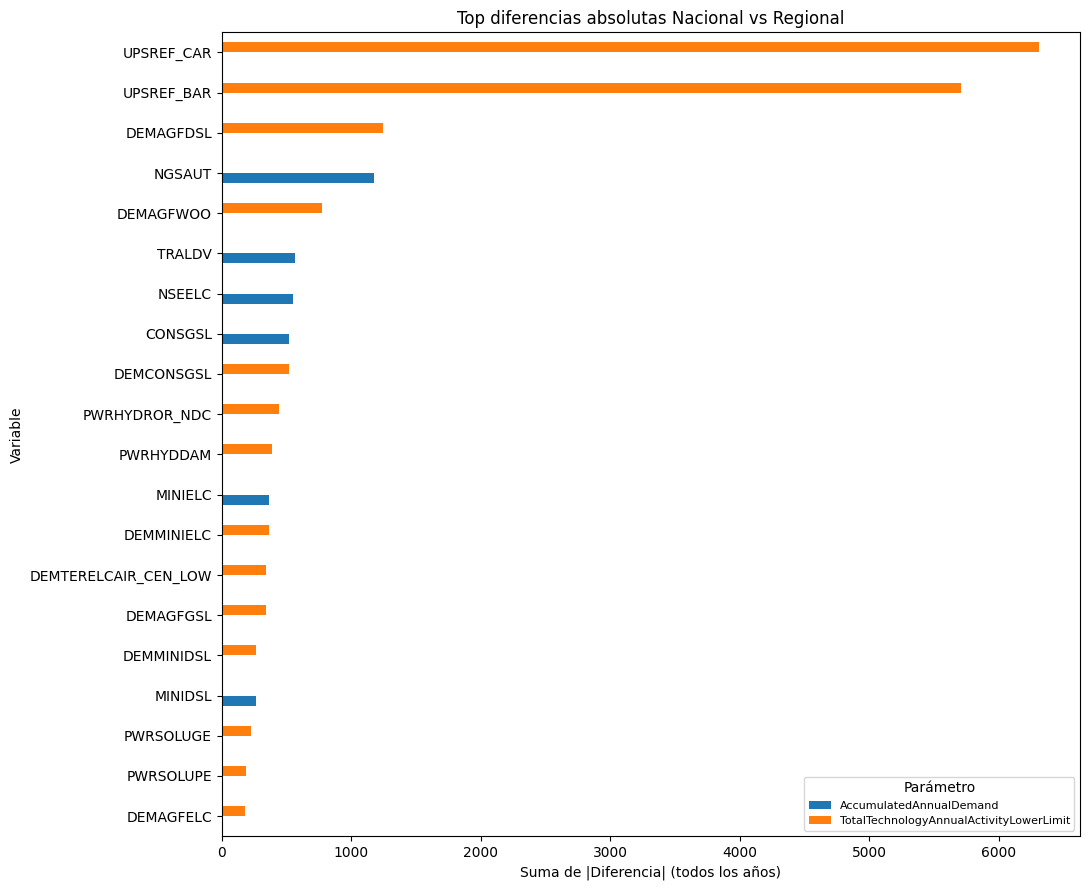

In [8]:
RUTA_PNG = paths["outputs"]["reportes"] / "top_diferencias.png"

if MODO_COMPARACION != "general":
    display(Markdown(f"**Top-{TOP_N} diferencias absolutas por tecnología/fuel**"))
    display(reporte.top_diferencias(comparacion, n=TOP_N))
    reporte.grafica_top_diferencias(comparacion, n=TOP_N, ruta_png=RUTA_PNG)
else:
    reporte.grafica_discrepancias_por_parametro(discrepancias)

## 5. Exportar reporte

El Excel se escribe **una sola vez en la sección 8** (reporte extendido), que incluye
estas mismas hojas — **Comparacion** (filas sobre el umbral resaltadas en rojo vía
formato condicional), **Anomalias**, **Resumen** — más las adicionales. Exportarlo
también aquí duplicaba minutos de escritura en modo `general`.

In [ ]:
# El export del Excel se difiere a la sección 8 para no escribirlo dos veces.
RUTA_REPORTE = paths["outputs"]["reportes"] / "Reporte_Comparacion_Nacional_vs_Regional.xlsx"
print(f"Export diferido a la sección 8 → {RUTA_REPORTE.name}")
if MODO_COMPARACION != "general":
    print(f"Gráfica : {RUTA_PNG}")

## 6. Análisis profundo por sector

Para cada sector activo (TRA, IND, RES, TER, AGF, PWR — detección por `contains()`
sobre `TECHNOLOGY`/`FUEL`): inventario del sector, validación de los parámetros clave
(`comparador.PARAMS_CLAVE_SECTOR`; los vacíos en el SAND se saltan) y desglose
variable × región del parámetro con más datos. En modo `parametro`/`lista_parametros`
solo se validan los parámetros del filtro, para los sectores implícitos en ellos.

In [10]:
# --- 6. Análisis profundo por sector (comparador.analisis_por_sector) ---
parametros_analisis = None if MODO_COMPARACION == "general" else PARAMETROS_FILTRO
ambito = df_nacional if MODO_COMPARACION == "general" \
    else df_nacional[df_nacional["Parameter"].isin(PARAMETROS_FILTRO)]
sectores_activos = comparador.detectar_sectores(ambito)
print(f"Sectores activos: {sectores_activos}")

df_reg_prep = comparador.preparar_regional(df_regional,
                                           list(params_cfg["prefijo_region"].values()))

def _resaltar_discrepancias(df, col_pct="Diferencia_Pct"):
    """Filas en rojo cuando |Diferencia %| supera el umbral configurado."""
    def fila_roja(fila):
        pct = fila.get(col_pct)
        alerta = pd.notna(pct) and abs(pct) > UMBRAL_ALERTA
        return ["background-color: #FFC7CE; color: #9C0006" if alerta else ""] * len(fila)
    return df.style.apply(fila_roja, axis=1).hide(axis="index")

analisis_sectores = {}
for n_sector, sector in enumerate(sectores_activos, start=1):
    display(Markdown(f"### 6.{n_sector} Sector {sector}"))
    res = comparador.analisis_por_sector(
        df_nacional, df_regional, sector, otoole["param"], params_cfg,
        diccionario_tech=MAPEOS["diccionario_tech"],
        diccionario_fuel=MAPEOS["diccionario_fuel"],
        parametros=parametros_analisis, df_reg_prep=df_reg_prep,
    )
    analisis_sectores[sector] = res

    # 6.x.1 Inventario del sector
    display(Markdown(f"**6.{n_sector}.1 Inventario** — {res['filas_nacional']:,} filas "
                     f"Nacional / {res['filas_regional']:,} filas Regional"))
    inv_sector = pd.concat([res["inventario_tech"], res["inventario_fuel"]],
                           ignore_index=True)
    if not inv_sector.empty:
        display(inv_sector.groupby(["Dimension", "Categoria"], as_index=False).size())
    if res["modos_tra"] is not None and not res["modos_tra"].empty:
        display(Markdown("Desglose por modo de transporte:"))
        display(res["modos_tra"])

    # 6.x.2 Validación de parámetros clave (mismas rutas aditiva/intensiva del comparador)
    display(Markdown(f"**6.{n_sector}.2 Validación de parámetros clave**"))
    if res["resumen_validacion"].empty:
        display(Markdown("_Sin datos del sector en los parámetros clave "
                         "(o quedaron fuera del filtro)._"))
    else:
        display(res["resumen_validacion"])
        disc = res["validacion"][~res["validacion"]["Coincide"]]
        if not disc.empty:
            display(Markdown(f"Mayores discrepancias ({len(disc):,} filas en total):"))
            display(_resaltar_discrepancias(disc.head(15)))

    # 6.x.3 Desglose variable × región
    if not res["desglose"].empty:
        display(Markdown(f"**6.{n_sector}.3 Desglose por región** — "
                         f"`{res['parametro_desglose']}`, año {res['anio_desglose']} "
                         "(la columna Advertencia_Renombramiento marca FUELs renombrados)"))
        display(_resaltar_discrepancias(res["desglose"].head(30)))

Sectores activos: ['TRA', 'IND', 'RES', 'TER', 'AGF', 'PWR']


### 6.1 Sector TRA

12:19:35 INFO    comparador: Sector TRA: 10461 filas nac / 5623 filas reg, 2 parámetros clave validados


**6.1.1 Inventario** — 10,461 filas Nacional / 5,623 filas Regional

,Dimension,Categoria,size
0,FUEL,En ambos,21
1,FUEL,Solo Nacional,35
2,FUEL,Solo Regional (base),5
3,TECHNOLOGY,En ambos,63
4,TECHNOLOGY,Solo Nacional,3
5,TECHNOLOGY,Solo Regional (base),16


...

,Sector,Parametro,Tipo,Filas,Filas_OK,Filas_Discrepancia,Pct_Discrepancia,Max_Diferencia_Abs
0,PWR,TotalTechnologyAnnualActivityLowerLimit,aditivo,858,471,387,45.100000,19.130579


Mayores discrepancias (387 filas en total):

Parametro,TECHNOLOGY,Año,Valor_Nacional,Valor_Regional,Region,Diferencia,Diferencia_Pct,Coincide
TotalTechnologyAnnualActivityLowerLimit,PWRAFR,2022,0.000000,2.725000,SUMA_REGIONES,-2.725000,nan,False
TotalTechnologyAnnualActivityLowerLimit,PWRBGS,2022,0.003688,0.003000,SUMA_REGIONES,0.000688,0.186646,False
TotalTechnologyAnnualActivityLowerLimit,PWRCOA,2022,12.415231,12.462000,SUMA_REGIONES,-0.046769,-0.003767,False
TotalTechnologyAnnualActivityLowerLimit,PWRFOL,2022,1.354645,1.355000,SUMA_REGIONES,-0.000355,-0.000262,False
TotalTechnologyAnnualActivityLowerLimit,PWRHYDDAM,2022,202.053786,217.518000,SUMA_REGIONES,-15.464214,-0.076535,False
TotalTechnologyAnnualActivityLowerLimit,PWRHYDROR,2022,11.265940,13.278000,SUMA_REGIONES,-2.012060,-0.178597,False
TotalTechnologyAnnualActivityLowerLimit,PWRHYDROR_NDC,2022,17.698089,0.000000,SUMA_REGIONES,17.698089,1.000000,False
TotalTechnologyAnnualActivityLowerLimit,PWRJET,2022,0.014762,0.015000,SUMA_REGIONES,-0.000238,-0.016122,False
TotalTechnologyAnnualActivityLowerLimit,PWRNGS_CC,2022,17.481600,13.067000,SUMA_REGIONES,4.414600,0.252528,False
TotalTechnologyAnnualActivityLowerLimit,PWRNGS_CS,2022,9.478800,7.974000,SUMA_REGIONES,1.504800,0.158754,False


**6.6.3 Desglose por región** — `TotalTechnologyAnnualActivityLowerLimit`, año 2022 (la columna Advertencia_Renombramiento marca FUELs renombrados)

Variable,Nacional,AN,CA,NE,OR,SO,Suma_Regional,Diferencia_Pct
PWRAFR,0.000000,nan,nan,nan,0.167000,2.558000,2.725000,nan
PWRBGS,0.003688,nan,nan,nan,0.003000,nan,0.003000,0.186646
PWRCOA,12.415231,nan,7.879000,3.809000,0.728000,0.046000,12.462000,-0.003767
PWRCOACCS,0.000000,nan,nan,nan,nan,nan,nan,nan
PWRCSP,0.000000,nan,nan,nan,nan,nan,nan,nan
PWRDSL,4.429993,4.372000,nan,nan,nan,0.058000,4.430000,-0.000002
PWRFOL,1.354645,nan,1.355000,nan,nan,nan,1.355000,-0.000262
PWRGEO,0.000000,nan,nan,nan,nan,nan,nan,nan
PWRHYDDAM,202.053786,104.215000,6.430000,35.691000,30.069000,41.113000,217.518000,-0.076535
PWRHYDROR,11.265940,5.010000,nan,nan,3.043000,5.225000,13.278000,-0.178597


## 7. Contextualización de anomalías con archivos de mapeo

Cruza las anomalías `SIN_CORRESPONDENCIA` / `TECHNOLOGY_NO_EN_REGIONAL` /
`FUEL_NO_EN_REGIONAL` contra `Insumos/Mapeo/mapeo_tech_fuel.xlsx` y sugiere una acción:
`cambio_de_nombre` | `no_existe_en_region` | `verificar_creacion` | `sin_info`.

In [11]:
# --- 7. Anomalías contextualizadas (requiere mapeo_tech_fuel.xlsx) ---
anomalias_ctx = None
if MAPEOS["mapeo"] is None:
    display(Markdown("_Sección 7 omitida: no existe `Insumos/Mapeo/mapeo_tech_fuel.xlsx`._"))
elif anomalias.empty:
    display(Markdown("_Sin anomalías que contextualizar._"))
else:
    anomalias_ctx = comparador.contextualizar_anomalias(anomalias, MAPEOS["mapeo"])
    display(Markdown(f"**{len(anomalias_ctx)} anomalías contextualizadas** "
                     f"(de {len(anomalias)} totales; solo los tipos "
                     f"{', '.join(comparador.TIPOS_ANOMALIA_CONTEXTUALIZABLES)}):"))
    display(anomalias_ctx.groupby("ACCION_SUGERIDA", as_index=False).size()
            .sort_values("size", ascending=False))
    display(anomalias_ctx.head(30))

**586 anomalías contextualizadas** (de 666 totales; solo los tipos SIN_CORRESPONDENCIA, TECHNOLOGY_NO_EN_REGIONAL, FUEL_NO_EN_REGIONAL):

,ACCION_SUGERIDA,size
2,verificar_creacion,482
1,no_existe_en_region,82
0,cambio_de_nombre,22


,Parametro,Tecnologia_Fuel,Tipo_Anomalia,Detalle,TIENE_MAPEO,REGIONES_ESPERADAS,NOMBRE_REGIONAL,ACCION_SUGERIDA
0,AccumulatedAnnualDemand,BAG,SIN_CORRESPONDENCIA,Ningún XX_<código> existe en el escenario regi...,True,"OR, SO",,verificar_creacion
1,AccumulatedAnnualDemand,BDL,SIN_CORRESPONDENCIA,Ningún XX_<código> existe en el escenario regi...,True,"AN, CA, NE, OR, SO",BDL002,cambio_de_nombre
2,AccumulatedAnnualDemand,BET,SIN_CORRESPONDENCIA,Ningún XX_<código> existe en el escenario regi...,True,"AN, CA, NE, OR, SO",BET002,cambio_de_nombre
3,AccumulatedAnnualDemand,BGS,SIN_CORRESPONDENCIA,Ningún XX_<código> existe en el escenario regi...,True,"AN, CA, NE, OR, SE, SO",,verificar_creacion
4,AccumulatedAnnualDemand,BMET,SIN_CORRESPONDENCIA,Ningún XX_<código> existe en el escenario regi...,True,"AN, CA, NE, OR, SO",,verificar_creacion
5,AccumulatedAnnualDemand,BMETL,SIN_CORRESPONDENCIA,Ningún XX_<código> existe en el escenario regi...,True,"AN, CA, NE, OR, SO",,verificar_creacion
6,AccumulatedAnnualDemand,COA,SIN_CORRESPONDENCIA,Ningún XX_<código> existe en el escenario regi...,True,"AN, NE, OR, SO",COA001,cambio_de_nombre
7,AccumulatedAnnualDemand,COA002,SIN_CORRESPONDENCIA,Ningún XX_<código> existe en el escenario regi...,True,"AN, CA, NE, OR, SO",,verificar_creacion
8,AccumulatedAnnualDemand,CONSDSL,SIN_CORRESPONDENCIA,Ningún XX_<código> existe en el escenario regi...,True,"AN, CA, NE, OR, SO",,verificar_creacion
9,AccumulatedAnnualDemand,CONSELC,SIN_CORRESPONDENCIA,Ningún XX_<código> existe en el escenario regi...,True,"AN, CA, NE, OR, SO",,verificar_creacion


## 8. Exportar reporte extendido

Reexporta el mismo Excel de la sección 5 agregando las hojas **Inventario_Tech_Fuel**
y **Por_Sector** (solo en modo `general`), **Sector_Detalle** (sectores analizados en
la sección 6) y **Anomalias_Contextualizadas** (si existe el mapeo). Las hojas que no
aplican según el modo se omiten con advertencia.

In [ ]:
# --- 8. Reporte extendido: hojas adicionales sobre el mismo Excel ---
hojas_extra = {}

if MODO_COMPARACION == "general" and inventario is not None:
    hojas_extra["Inventario_Tech_Fuel"] = pd.concat(
        [inventario["tech"], inventario["fuel"]], ignore_index=True)
    hojas_extra["Por_Sector"] = comparador.tabla_por_sector(analisis_sectores)
else:
    print("Advertencia: hojas Inventario_Tech_Fuel y Por_Sector omitidas "
          f"(MODO_COMPARACION = '{MODO_COMPARACION}', requieren 'general').")

detalle_sectores = [r["resumen_validacion"] for r in analisis_sectores.values()
                    if not r["resumen_validacion"].empty]
if detalle_sectores:
    hojas_extra["Sector_Detalle"] = pd.concat(detalle_sectores, ignore_index=True)
else:
    print("Advertencia: hoja Sector_Detalle omitida (sin sectores con datos).")

if anomalias_ctx is not None and not anomalias_ctx.empty:
    hojas_extra["Anomalias_Contextualizadas"] = anomalias_ctx
else:
    print("Advertencia: hoja Anomalias_Contextualizadas omitida (sin mapeo o sin anomalías).")

ruta_reporte = reporte.exportar_reporte_comparacion(
    RUTA_REPORTE,
    comparacion, anomalias, resultado["resumen"],
    umbral_alerta_pct=UMBRAL_ALERTA,
    hojas_extra=hojas_extra,
)
print(f"Reporte extendido: {ruta_reporte}")
print(f"Hojas extra incluidas: {[h for h, df in hojas_extra.items() if df is not None and not df.empty]}")

---
*Smoke tests de los módulos: `python tests/test_smoke.py` desde la raíz del proyecto.*